Sankey saved to: rocm_type_subcategory_outcome_sankey.png


Runtime chart saved to: rocm_success_runtime_seaborn.png


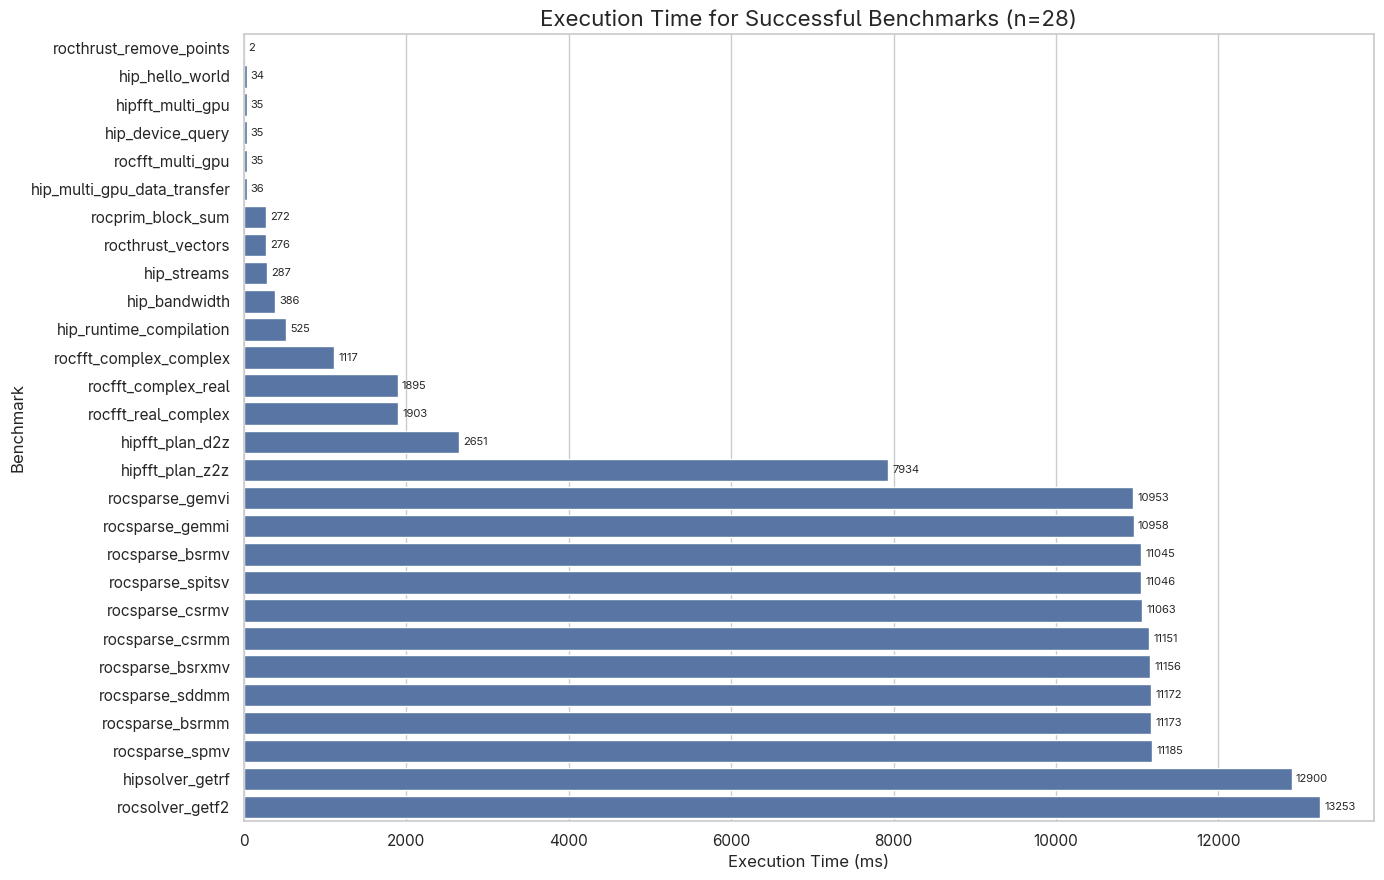

In [2]:
import os
from collections import defaultdict

import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load and Clean Benchmark Records
# -------------------------------------------------------------------------
csv_path = "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/Experiments/rocm-examples from src/benchmark_results.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing '{csv_path}'.")

df = pd.read_csv(csv_path, sep="|")
df["error_category"] = df["error_category"].fillna("Unknown Error")

# -------------------------------------------------------------------------
# Helpers: type + subcategory classification
# -------------------------------------------------------------------------
def benchmark_type(binary: str) -> str:
    # Simple rule: roc* -> ROC, everything else -> HIP
    return "ROC" if binary.startswith("roc") else "HIP"

def benchmark_subcategory(binary: str) -> str:
    prefix = binary.split("_")[0]

    # Human-friendly labels, kept unique once combined with type
    labels = {
        "hip": "Core",
        "applications": "Applications",
        "reduction": "Reduction",
        "hipblas": "BLAS",
        "hipcub": "CUB",
        "hipfft": "FFT",
        "hipsolver": "Solver",
        "rocblas": "BLAS",
        "rocfft": "FFT",
        "rocprim": "Prim",
        "rocrand": "Rand",
        "rocsolver": "Solver",
        "rocsparse": "Sparse",
        "rocthrust": "Thrust",
    }
    return labels.get(prefix, prefix.capitalize())

df["benchmark_type"] = df["binary"].apply(benchmark_type)
df["subcategory"] = df["binary"].apply(benchmark_subcategory)

# -------------------------------------------------------------------------
# Build Sankey flows:
# rocm-examples -> HIP/ROC -> type:subcategory -> Success/Failure -> error_category
# -------------------------------------------------------------------------
root_node = "rocm-examples"
success_node = "Success"
failure_node = "Failure"

nodes = [root_node, success_node, failure_node]
flows = []

def sub_node_name(t: str, s: str) -> str:
    return f"{t}: {s}"

for _, row in df.iterrows():
    t = row["benchmark_type"]              # HIP / ROC
    s = row["subcategory"]                 # BLAS / Sparse / etc.
    sub_node = sub_node_name(t, s)

    nodes.extend([t, sub_node])

    # Root -> type
    flows.append((root_node, t, 1))
    # Type -> subcategory
    flows.append((t, sub_node, 1))

    if row["status"] == "Success":
        # Subcategory -> Success
        flows.append((sub_node, success_node, 1))
    else:
        err = row["error_category"]
        nodes.append(err)
        # Subcategory -> Failure -> error category
        flows.append((sub_node, failure_node, 1))
        flows.append((failure_node, err, 1))

# Deduplicate node labels while preserving order
unique_nodes = list(dict.fromkeys(nodes))
node_indices = {name: idx for idx, name in enumerate(unique_nodes)}

# Aggregate identical links
aggregated_flows = defaultdict(int)
for src, tgt, val in flows:
    aggregated_flows[(node_indices[src], node_indices[tgt])] += val

plotly_sources = []
plotly_targets = []
plotly_values = []
for (s_idx, t_idx), val in aggregated_flows.items():
    plotly_sources.append(s_idx)
    plotly_targets.append(t_idx)
    plotly_values.append(val)

# -------------------------------------------------------------------------
# Colors
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.80)",
    "hip": "rgba(59, 130, 246, 0.80)",
    "roc": "rgba(16, 185, 129, 0.80)",
    "success": "rgba(44, 123, 182, 0.80)",
    "failure": "rgba(215, 25, 28, 0.80)",
    "error": "rgba(239, 68, 68, 0.70)",
    "flow_success": "rgba(44, 123, 182, 0.25)",
    "flow_failure": "rgba(215, 25, 28, 0.25)",
}

node_colors = []
for name in unique_nodes:
    if name == root_node:
        node_colors.append(color_map["neutral"])
    elif name == success_node:
        node_colors.append(color_map["success"])
    elif name == failure_node:
        node_colors.append(color_map["failure"])
    elif name in ("HIP", "ROC"):
        node_colors.append(color_map["hip"] if name == "HIP" else color_map["roc"])
    elif ": " in name:
        # type:subcategory nodes
        node_colors.append(color_map["hip"] if name.startswith("HIP:") else color_map["roc"])
    else:
        # error categories
        node_colors.append(color_map["error"])

link_colors = []
for s_idx, t_idx in zip(plotly_sources, plotly_targets):
    source_name = unique_nodes[s_idx]
    target_name = unique_nodes[t_idx]

    if target_name in (success_node,) or source_name == success_node:
        link_colors.append(color_map["flow_success"])
    elif target_name == failure_node or source_name == failure_node or target_name in df["error_category"].unique():
        link_colors.append(color_map["flow_failure"])
    else:
        # root -> type, type -> subcategory
        link_colors.append("rgba(100, 116, 139, 0.22)")

# -------------------------------------------------------------------------
# Sankey figure
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=14,
                thickness=18,
                line=dict(color="rgba(255, 255, 255, 0.9)", width=0.5),
                label=unique_nodes,
                color=node_colors,
            ),
            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    title_text=f"rocm-examples v6.4.2 on gfx90c (installed via dnf, no spoofing) (Total Tests: {len(df)})",
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=20,
    font_family="Adwaita Sans, sans-serif",
    width=1400,
    height=950,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

sankey_output = "rocm_type_subcategory_outcome_sankey.png"
fig.write_image(sankey_output, scale=2)
print(f"Sankey saved to: {sankey_output}")
fig.show()

# -------------------------------------------------------------------------
# Separate seaborn chart for successful runtime only
# -------------------------------------------------------------------------
success_df = df[df["status"] == "Success"].copy()
success_df = success_df.sort_values("execution_time_ms", ascending=True)

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

plt.figure(figsize=(14, max(6, 0.32 * len(success_df))))
ax = sns.barplot(
    data=success_df,
    y="binary",
    x="execution_time_ms",
    order=success_df["binary"],
)

ax.set_title(
    f"Execution Time for Successful Benchmarks (n={len(success_df)})",
    fontsize=16,
)
ax.set_xlabel("Execution Time (ms)")
ax.set_ylabel("Benchmark")

# Optional value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)

plt.tight_layout()
runtime_output = "rocm_success_runtime_seaborn.png"
plt.savefig(runtime_output, dpi=200, bbox_inches="tight")
print(f"Runtime chart saved to: {runtime_output}")
plt.show()

Saved to: hip_basic_dnf_vs_source.png


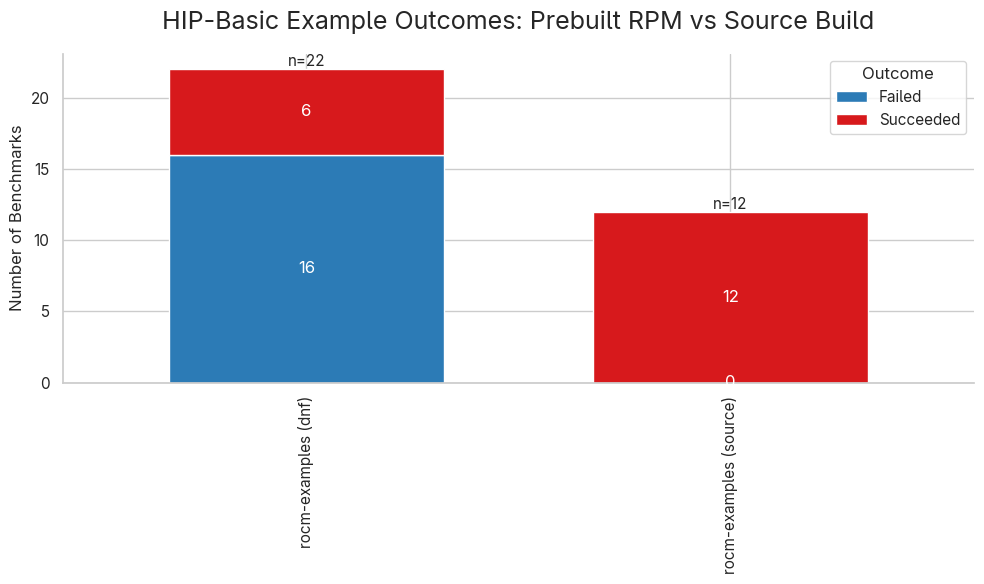

In [9]:
# -------------------------------------------------------------------------
# HIP-Basic: Prebuilt (dnf) vs Source Build Success Comparison
# -------------------------------------------------------------------------
# Reuses the existing visual language:
# - Adwaita Sans
# - Same blue/red palette used throughout the article
# - seaborn + matplotlib
# -------------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load benchmark results from the original dnf experiment CSV
# -------------------------------------------------------------------------
csv_path = "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/Experiments/rocm-examples from dnf/benchmark_results.csv"

dnf_df = pd.read_csv(csv_path, sep="|")

# Restrict to HIP-Basic examples only.
# Everything beginning with "hip_" in the benchmark suite.
hip_basic_df = dnf_df[dnf_df["binary"].str.startswith("hip_")].copy()

# -------------------------------------------------------------------------
# Source build results (manually verified)
# -------------------------------------------------------------------------
#
# These are the HIP-Basic examples you reported after building from source.
#
# Success:
#   hip_device_query
#   hip_assembly_to_executable
#   hip_llvm_ir_to_executable
#   hip_bandwidth
#   hip_events
#   hip_hello_world
#   hip_module_api
#   hip_cooperative_groups
#   hip_bit_extract
#   hip_device_globals
#   hip_dynamic_shared
#   hip_gpu_arch
#
# Failures:
#   None observed (hipify build issue excluded since it is not a runtime test)
#
src_success = 12
src_failure = 0

# -------------------------------------------------------------------------
# Aggregate counts
# -------------------------------------------------------------------------
dnf_success = (hip_basic_df["status"] == "Success").sum()
dnf_failure = (hip_basic_df["status"] != "Success").sum()

plot_df = pd.DataFrame(
    [
        ["rocm-examples (dnf)", "Succeeded", dnf_success],
        ["rocm-examples (dnf)", "Failed", dnf_failure],
        ["rocm-examples (source)", "Succeeded", src_success],
        ["rocm-examples (source)", "Failed", src_failure],
    ],
    columns=["Build", "Outcome", "Count"],
)

# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------
sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "Adwaita Sans"

palette = {
    "Succeeded": "rgba(44, 123, 182, 0.80)",  # same success blue
    "Failed": "rgba(215, 25, 28, 0.80)",      # same failure red
}

# Matplotlib expects hex colors
palette = {
    "Succeeded": "#2c7bb6",
    "Failed": "#d7191c",
}

# Pivot for stacked plotting
pivot_df = (
    plot_df.pivot(index="Build", columns="Outcome", values="Count")
    .fillna(0)
    .astype(int)
)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

pivot_df.plot(
    kind="bar",
    stacked=True,
    color=[palette["Succeeded"], palette["Failed"]],
    ax=ax,
    width=0.65,
)

ax.set_title(
    "HIP-Basic Example Outcomes: Prebuilt RPM vs Source Build",
    fontsize=18,
    pad=18,
)

ax.set_xlabel("")
ax.set_ylabel("Number of Benchmarks")

ax.legend(
    title="Outcome",
    frameon=True,
)

# -------------------------------------------------------------------------
# Value labels
# -------------------------------------------------------------------------
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=12,
        color="white",
        fontweight="bold",
    )

# Add totals above each bar
totals = pivot_df.sum(axis=1)

for idx, total in enumerate(totals):
    ax.text(
        idx,
        total + 0.2,
        f"n={total}",
        ha="center",
        fontsize=11,
    )

sns.despine()

plt.tight_layout()

output = "hip_basic_dnf_vs_source.png"
plt.savefig(output, dpi=200, bbox_inches="tight")

print(f"Saved to: {output}")
plt.show()

/tmp/ipykernel_704045/32680477.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0)


Saved to: hip_basic_rpm_vs_source.png

RPM Success:
hip_bandwidth
hip_device_query
hip_hello_world

RPM Failure:
hip_bit_extract
hip_cooperative_groups
hip_device_globals
hip_dynamic_shared
hip_events
hip_gpu_arch
hip_module_api

Source Success:
hip_assembly_to_executable
hip_llvm_ir_to_executable
hip_bandwidth
hip_bit_extract
hip_cooperative_groups
hip_device_globals
hip_device_query
hip_dynamic_shared
hip_events
hip_gpu_arch
hip_hello_world
hip_module_api


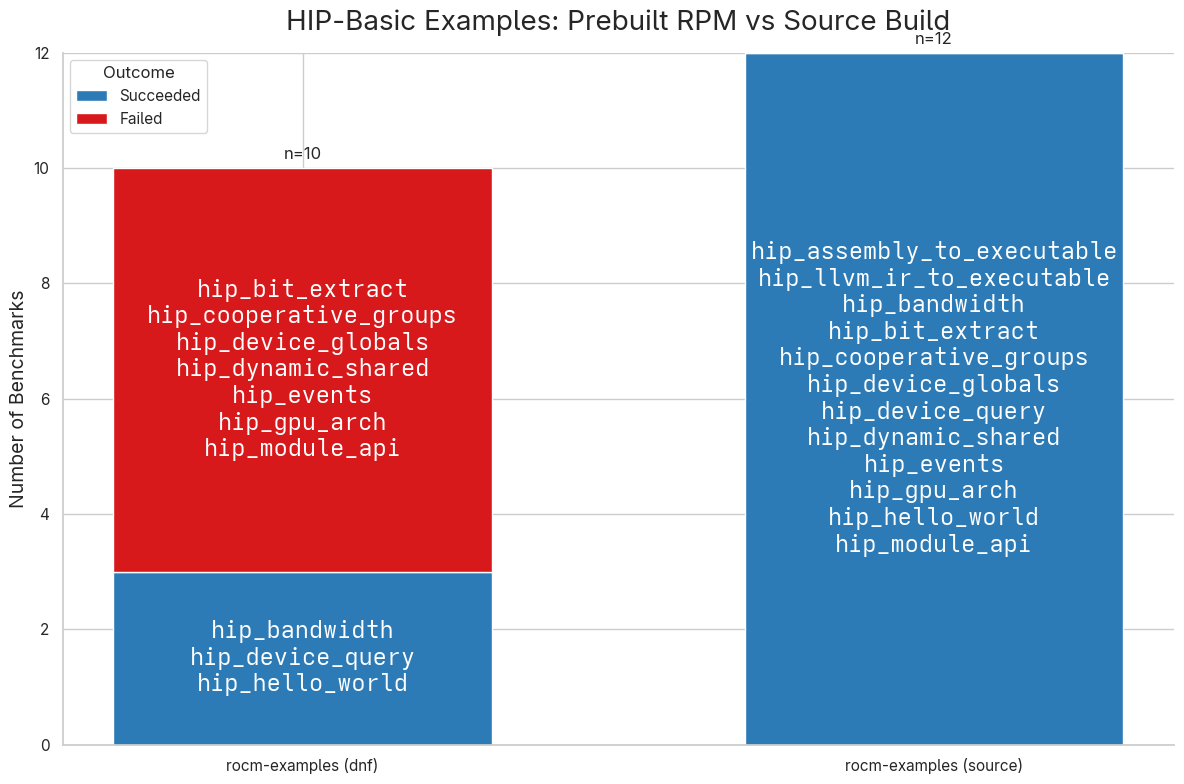

In [21]:
# -------------------------------------------------------------------------
# HIP-Basic Only: RPM vs Source Build
#
# Improvements:
# - Blue = Success, Red = Failure
# - Horizontal x-axis labels
# - Actual benchmark names rendered inside bars (one per line)
# - Source ordering starts with:
#       hip_assembly_to_executable
#       hip_llvm_ir_to_executable
# -------------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load benchmark CSV
# -------------------------------------------------------------------------

csv_path = (
    "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/"
    "Experiments/rocm-examples from dnf/benchmark_results.csv"
)

df = pd.read_csv(csv_path, sep="|")

# -------------------------------------------------------------------------
# Exact HIP-Basic set
# -------------------------------------------------------------------------

hip_basic_examples = [
    "hip_assembly_to_executable",
    "hip_llvm_ir_to_executable",
    "hip_bandwidth",
    "hip_bit_extract",
    "hip_cooperative_groups",
    "hip_device_globals",
    "hip_device_query",
    "hip_dynamic_shared",
    "hip_events",
    "hip_gpu_arch",
    "hip_hello_world",
    "hip_module_api",
]

# -------------------------------------------------------------------------
# RPM Results
# -------------------------------------------------------------------------

rpm_df = df[df["binary"].isin(hip_basic_examples)].copy()

rpm_success_examples = sorted(
    rpm_df[rpm_df["status"] == "Success"]["binary"].tolist()
)

rpm_failure_examples = sorted(
    rpm_df[rpm_df["status"] != "Success"]["binary"].tolist()
)

rpm_success = len(rpm_success_examples)
rpm_failure = len(rpm_failure_examples)

# -------------------------------------------------------------------------
# Source Results
# -------------------------------------------------------------------------

src_success_examples = hip_basic_examples
src_failure_examples = []

src_success = len(src_success_examples)
src_failure = 0

# -------------------------------------------------------------------------
# Plot setup
# -------------------------------------------------------------------------

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(12, 8))

labels = [
    "rocm-examples (dnf)",
    "rocm-examples (source)",
]

success_counts = [rpm_success, src_success]
failure_counts = [rpm_failure, src_failure]

# Success layer (BLUE)
success_bars = ax.bar(
    labels,
    success_counts,
    color="#2c7bb6",
    label="Succeeded",
    width=0.6,
)

# Failure layer (RED)
failure_bars = ax.bar(
    labels,
    failure_counts,
    bottom=success_counts,
    color="#d7191c",
    label="Failed",
    width=0.6,
)

# -------------------------------------------------------------------------
# Text labels
# -------------------------------------------------------------------------

rpm_success_text = "\n".join(rpm_success_examples)

rpm_failure_text = "\n".join(rpm_failure_examples)

src_success_text = "\n".join(src_success_examples)

# Success text
ax.text(
    0,
    rpm_success / 2,
    rpm_success_text,
    ha="center",
    va="center",
    fontsize=17,
    color="white",
    fontfamily="Adwaita Mono",
)

ax.text(
    1,
    src_success / 2,
    src_success_text,
    ha="center",
    va="center",
    fontsize=17,
    color="white",
    fontfamily="Adwaita Mono",
)

# Failure text
if rpm_failure:
    ax.text(
        0,
        rpm_success + (rpm_failure / 2),
        rpm_failure_text,
        ha="center",
        va="center",
        fontsize=17,
        color="white",
        fontfamily="Adwaita Mono",
    )

# Totals
ax.text(
    0,
    rpm_success + rpm_failure + 0.15,
    f"n={rpm_success + rpm_failure}",
    ha="center",
    fontsize=12,
)

ax.text(
    1,
    src_success + 0.15,
    f"n={src_success}",
    ha="center",
    fontsize=12,
)

# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------

ax.set_title(
    "HIP-Basic Examples: Prebuilt RPM vs Source Build",
    fontsize=20,
    pad=16,
)

ax.set_ylabel("Number of Benchmarks", fontsize=14)
ax.set_xlabel("")

# Horizontal x labels
ax.set_xticklabels(labels, rotation=0)

ax.legend(
    title="Outcome",
    loc="upper left",
)

sns.despine()

plt.tight_layout()

output = "hip_basic_rpm_vs_source.png"

plt.savefig(
    output,
    dpi=200,
    bbox_inches="tight",
)

print(f"Saved to: {output}")
print()
print("RPM Success:")
print("\n".join(rpm_success_examples))
print()
print("RPM Failure:")
print("\n".join(rpm_failure_examples))
print()
print("Source Success:")
print("\n".join(src_success_examples))

plt.show()

/tmp/ipykernel_704045/42811541.py:201: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


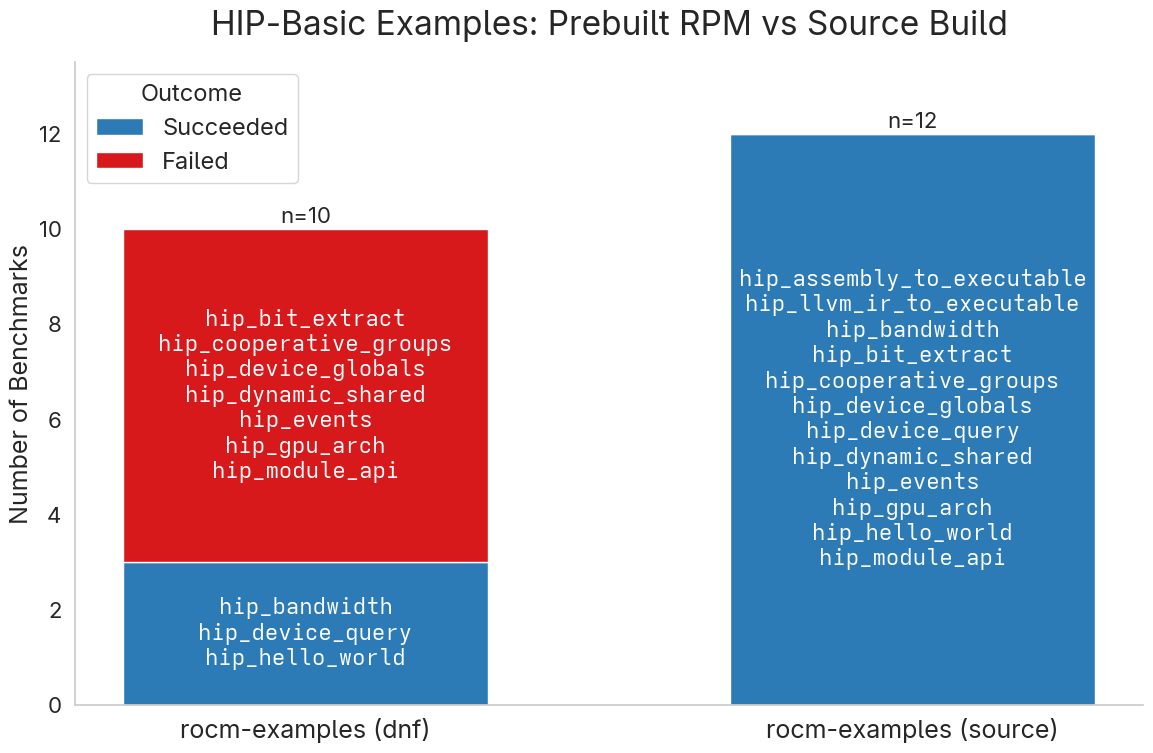

In [24]:
# -------------------------------------------------------------------------
# HIP-Basic Only: RPM vs Source Build
#
# Improvements:
# - Blue = Success, Red = Failure
# - Horizontal x-axis labels
# - Actual benchmark names rendered inside bars (one per line)
# - Source ordering starts with:
#       hip_assembly_to_executable
#       hip_llvm_ir_to_executable
# -------------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load benchmark CSV
# -------------------------------------------------------------------------

csv_path = (
    "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/"
    "Experiments/rocm-examples from src/benchmark_results.csv"
)

df = pd.read_csv(csv_path, sep="|")

# -------------------------------------------------------------------------
# Exact HIP-Basic set
# -------------------------------------------------------------------------

hip_basic_examples = [
    "hip_assembly_to_executable",
    "hip_llvm_ir_to_executable",
    "hip_bandwidth",
    "hip_bit_extract",
    "hip_cooperative_groups",
    "hip_device_globals",
    "hip_device_query",
    "hip_dynamic_shared",
    "hip_events",
    "hip_gpu_arch",
    "hip_hello_world",
    "hip_module_api",
]

# -------------------------------------------------------------------------
# RPM Results
# -------------------------------------------------------------------------

rpm_df = df[df["binary"].isin(hip_basic_examples)].copy()

rpm_success_examples = sorted(
    rpm_df[rpm_df["status"] == "Success"]["binary"].tolist()
)

rpm_failure_examples = sorted(
    rpm_df[rpm_df["status"] != "Success"]["binary"].tolist()
)

rpm_success = len(rpm_success_examples)
rpm_failure = len(rpm_failure_examples)

# -------------------------------------------------------------------------
# Source Results
# -------------------------------------------------------------------------

src_success_examples = hip_basic_examples
src_failure_examples = []

src_success = len(src_success_examples)
src_failure = 0

# -------------------------------------------------------------------------
# Plot setup
# -------------------------------------------------------------------------

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(12, 8))

labels = [
    "rocm-examples (dnf)",
    "rocm-examples (source)",
]

success_counts = [rpm_success, src_success]
failure_counts = [rpm_failure, src_failure]

# Success layer (BLUE)
success_bars = ax.bar(
    labels,
    success_counts,
    color="#2c7bb6",
    label="Succeeded",
    width=0.6,
)

# Failure layer (RED)
failure_bars = ax.bar(
    labels,
    failure_counts,
    bottom=success_counts,
    color="#d7191c",
    label="Failed",
    width=0.6,
)

# -------------------------------------------------------------------------
# Text labels
# -------------------------------------------------------------------------

rpm_success_text = "\n".join(rpm_success_examples)

rpm_failure_text = "\n".join(rpm_failure_examples)

src_success_text = "\n".join(src_success_examples)

# Success text
ax.text(
    0,
    rpm_success / 2,
    rpm_success_text,
    ha="center",
    va="center",
    fontsize=16,
    color="white",
    fontfamily="Adwaita Mono",
)

ax.text(
    1,
    src_success / 2,
    src_success_text,
    ha="center",
    va="center",
    fontsize=16,
    color="white",
    fontfamily="Adwaita Mono",
)

# Failure text
if rpm_failure:
    ax.text(
        0,
        rpm_success + (rpm_failure / 2),
        rpm_failure_text,
        ha="center",
        va="center",
        fontsize=16,
        color="white",
        fontfamily="Adwaita Mono",
    )

# -------------------------------------------------------------------------
# Totals
# -------------------------------------------------------------------------

ax.text(
    0,
    rpm_success + rpm_failure + 0.05,
    f"n={rpm_success + rpm_failure}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

ax.text(
    1,
    src_success + 0.05,
    f"n={src_success}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

# Give the figure breathing room above the bars.
ax.set_ylim(0, 13.5)

# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------

ax.set_title(
    "HIP-Basic Examples: Prebuilt RPM vs Source Build",
    fontsize=24,
    pad=20,
)

ax.set_ylabel(
    "Number of Benchmarks",
    fontsize=18,
)

ax.set_xlabel("")

# Horizontal x labels
ax.set_xticklabels(
    labels,
    rotation=0,
    fontsize=18,
)

ax.tick_params(
    axis="y",
    labelsize=16,
)

# Legend (+4 pt)
legend = ax.legend(
    title="Outcome",
    loc="upper left",
    fontsize=17,          # was effectively ~13
    title_fontsize=17,    # increase title too
)

# Optional: make legend text use Adwaita Sans explicitly.
for text in legend.get_texts():
    text.set_fontfamily("Adwaita Sans")

legend.get_title().set_fontfamily("Adwaita Sans")

sns.despine()
ax.grid(False)

plt.tight_layout(pad=2.0)

/tmp/ipykernel_704045/3309679961.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


Saved to: hip_basic_rpm_vs_source.png


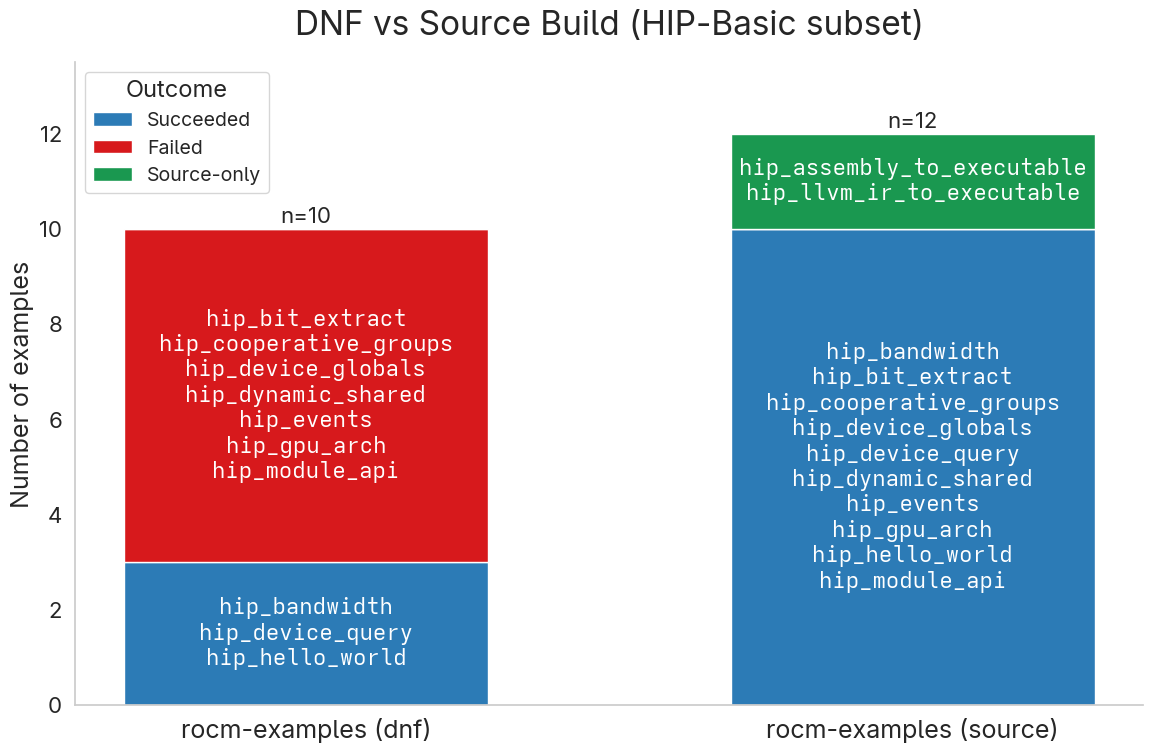

In [39]:
# -------------------------------------------------------------------------
# HIP-Basic Only: RPM vs Source Build
#
# Blue  : Successful examples present in the RPM benchmark suite.
# Red   : Failed examples present in the RPM benchmark suite.
# Green : Additional source-only examples not present in the RPM suite.
#
# Green examples:
#   - hip_assembly_to_executable
#   - hip_llvm_ir_to_executable
# -------------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load benchmark CSV
# -------------------------------------------------------------------------

csv_path = (
    "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/"
    "Experiments/rocm-examples from src/benchmark_results.csv"
)

df = pd.read_csv(csv_path, sep="|")

# -------------------------------------------------------------------------
# Exact HIP-Basic set
# -------------------------------------------------------------------------

hip_basic_examples = [
    "hip_assembly_to_executable",
    "hip_llvm_ir_to_executable",
    "hip_bandwidth",
    "hip_bit_extract",
    "hip_cooperative_groups",
    "hip_device_globals",
    "hip_device_query",
    "hip_dynamic_shared",
    "hip_events",
    "hip_gpu_arch",
    "hip_hello_world",
    "hip_module_api",
]

additional_examples = [
    "hip_assembly_to_executable",
    "hip_llvm_ir_to_executable",
]

regular_examples = [
    x for x in hip_basic_examples
    if x not in additional_examples
]

# -------------------------------------------------------------------------
# RPM Results
# -------------------------------------------------------------------------

rpm_df = df[df["binary"].isin(regular_examples)].copy()

rpm_success_examples = sorted(
    rpm_df[rpm_df["status"] == "Success"]["binary"].tolist()
)

rpm_failure_examples = sorted(
    rpm_df[rpm_df["status"] != "Success"]["binary"].tolist()
)

rpm_success = len(rpm_success_examples)
rpm_failure = len(rpm_failure_examples)

# -------------------------------------------------------------------------
# Source Results
# -------------------------------------------------------------------------

src_success_examples = [
    "hip_bandwidth",
    "hip_bit_extract",
    "hip_cooperative_groups",
    "hip_device_globals",
    "hip_device_query",
    "hip_dynamic_shared",
    "hip_events",
    "hip_gpu_arch",
    "hip_hello_world",
    "hip_module_api",
]

src_additional_examples = additional_examples

src_success = len(src_success_examples)
src_additional = len(src_additional_examples)

# -------------------------------------------------------------------------
# Plot setup
# -------------------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(12, 8))

labels = [
    "rocm-examples (dnf)",
    "rocm-examples (source)",
]

# Existing palette.
SUCCESS_BLUE = "#2c7bb6"
FAILURE_RED = "#d7191c"
EXTRA_GREEN = "#1a9850"

# -------------------------------------------------------------------------
# Bar layers
# -------------------------------------------------------------------------

# Blue
ax.bar(
    labels,
    [rpm_success, src_success],
    color=SUCCESS_BLUE,
    label="Succeeded",
    width=0.6,
)

# Red
ax.bar(
    labels,
    [rpm_failure, 0],
    bottom=[rpm_success, src_success],
    color=FAILURE_RED,
    label="Failed",
    width=0.6,
)

# Green
ax.bar(
    labels,
    [0, src_additional],
    bottom=[
        rpm_success + rpm_failure,
        src_success,
    ],
    color=EXTRA_GREEN,
    label="Source-only",
    width=0.6,
)

# -------------------------------------------------------------------------
# Text labels
# -------------------------------------------------------------------------

rpm_success_text = "\n".join(rpm_success_examples)

rpm_failure_text = "\n".join(rpm_failure_examples)

src_success_text = "\n".join(src_success_examples)

src_additional_text = "\n".join(src_additional_examples)

# RPM Success
ax.text(
    0,
    rpm_success / 2,
    rpm_success_text,
    ha="center",
    va="center",
    fontsize=16,
    color="white",
    fontfamily="Adwaita Mono",
)

# RPM Failure
if rpm_failure:
    ax.text(
        0,
        rpm_success + (rpm_failure / 2),
        rpm_failure_text,
        ha="center",
        va="center",
        fontsize=16,
        color="white",
        fontfamily="Adwaita Mono",
    )

# Source Success
ax.text(
    1,
    src_success / 2,
    src_success_text,
    ha="center",
    va="center",
    fontsize=16,
    color="white",
    fontfamily="Adwaita Mono",
)

# Source-only additions
ax.text(
    1,
    src_success + (src_additional / 2),
    src_additional_text,
    ha="center",
    va="center",
    fontsize=16,
    color="white",
    fontfamily="Adwaita Mono",
)

# -------------------------------------------------------------------------
# Totals
# -------------------------------------------------------------------------

rpm_total = rpm_success + rpm_failure
src_total = src_success + src_additional

ax.text(
    0,
    rpm_total + 0.05,
    f"n={rpm_total}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

ax.text(
    1,
    src_total + 0.05,
    f"n={src_total}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------

ax.set_ylim(0, 13.5)

ax.set_title(
    "DNF vs Source Build (HIP-Basic subset)",
    fontsize=24,
    pad=20,
)

ax.set_ylabel(
    "Number of examples",
    fontsize=18,
)

ax.set_xlabel("")

ax.set_xticklabels(
    labels,
    rotation=0,
    fontsize=18,
)

ax.tick_params(
    axis="y",
    labelsize=16,
)

legend = ax.legend(
    title="Outcome",
    loc="upper left",
    fontsize=14,
    title_fontsize=17,
)

for text in legend.get_texts():
    text.set_fontfamily("Adwaita Sans")

legend.get_title().set_fontfamily("Adwaita Sans")

# Remove grid lines.
ax.grid(False)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=False,
    bottom=False,
)

plt.tight_layout(pad=2.0)

# -------------------------------------------------------------------------
# Save figure
# -------------------------------------------------------------------------

output = "hip_basic_rpm_vs_source.png"

plt.savefig(
    output,
    dpi=300,
    bbox_inches="tight",
)

print(f"Saved to: {output}")

plt.show()

/tmp/ipykernel_704045/2056372549.py:302: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


Saved to: hip_basic_rpm_vs_source.png


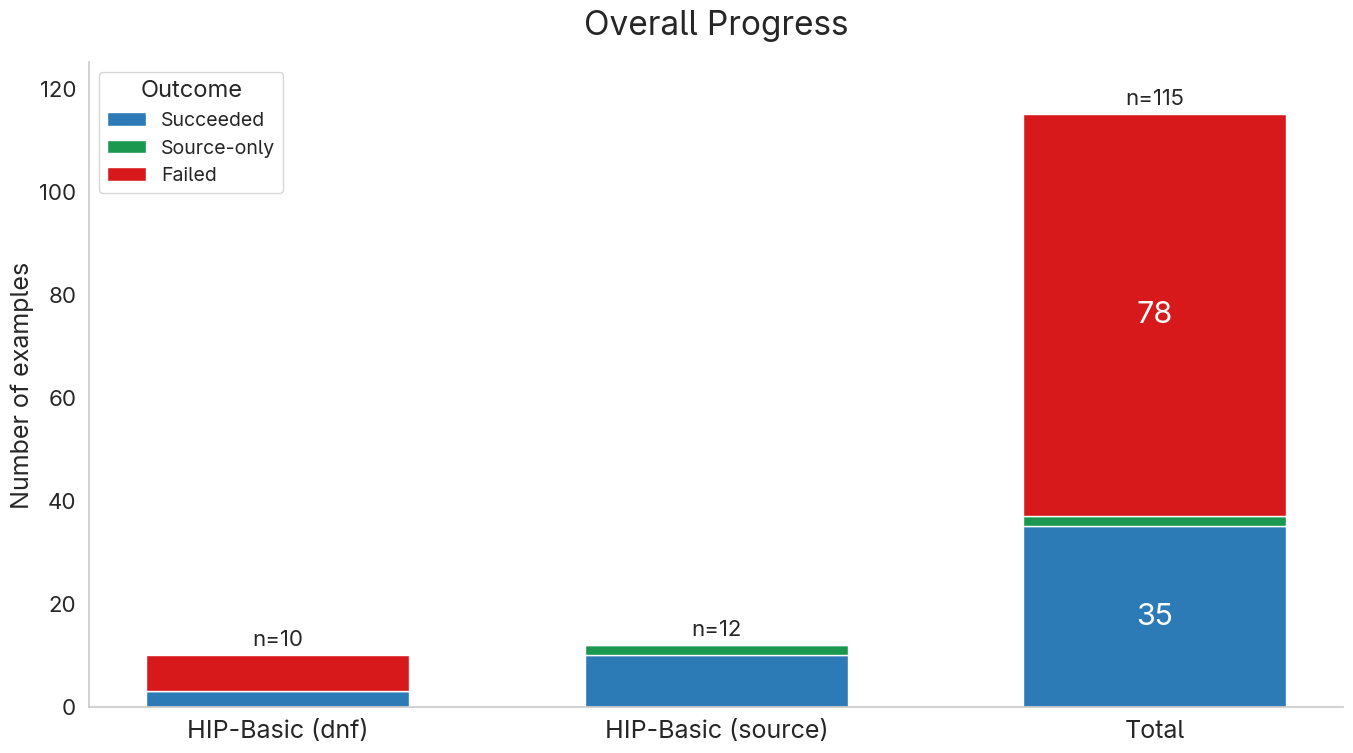

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Load benchmark CSV
# -------------------------------------------------------------------------

csv_path = (
    "/home/netherquark/Soham/Soham/Coding/AMD/ROCm/"
    "Experiments/rocm-examples from src/benchmark_results.csv"
)

df = pd.read_csv(csv_path, sep="|")

# -------------------------------------------------------------------------
# HIP-Basic subset
# -------------------------------------------------------------------------

hip_basic_examples = [
    "hip_assembly_to_executable",
    "hip_llvm_ir_to_executable",
    "hip_bandwidth",
    "hip_bit_extract",
    "hip_cooperative_groups",
    "hip_device_globals",
    "hip_device_query",
    "hip_dynamic_shared",
    "hip_events",
    "hip_gpu_arch",
    "hip_hello_world",
    "hip_module_api",
]

additional_examples = [
    "hip_assembly_to_executable",
    "hip_llvm_ir_to_executable",
]

regular_examples = [
    x for x in hip_basic_examples
    if x not in additional_examples
]

# -------------------------------------------------------------------------
# HIP-Basic RPM Results
# -------------------------------------------------------------------------

rpm_df = df[df["binary"].isin(regular_examples)].copy()

rpm_success_examples = sorted(
    rpm_df[rpm_df["status"] == "Success"]["binary"].tolist()
)

rpm_failure_examples = sorted(
    rpm_df[rpm_df["status"] != "Success"]["binary"].tolist()
)

rpm_success = len(rpm_success_examples)
rpm_failure = len(rpm_failure_examples)

# -------------------------------------------------------------------------
# HIP-Basic Source Results
# -------------------------------------------------------------------------

src_success_examples = [
    "hip_bandwidth",
    "hip_bit_extract",
    "hip_cooperative_groups",
    "hip_device_globals",
    "hip_device_query",
    "hip_dynamic_shared",
    "hip_events",
    "hip_gpu_arch",
    "hip_hello_world",
    "hip_module_api",
]

src_additional_examples = additional_examples

src_success = len(src_success_examples)
src_additional = len(src_additional_examples)

# -------------------------------------------------------------------------
# Global benchmark totals
#
# RPM benchmark suite:
#   - 113 benchmarks
#   - 28 succeeded
#   - 85 failed
#
# Additional source-only:
#   - 2 benchmarks added to the benchmark universe
#
# Additional successful source ports:
#   - 7 RPM failures became successful when built from source
#
# Best-case total:
#   - Success      = 28 + 7 = 35
#   - Source-only  = 2
#   - Failure      = 115 - 35 - 2 = 78
# -------------------------------------------------------------------------

TOTAL_RPM_BENCHMARKS = 113
TOTAL_SOURCE_ONLY = 2

TOTAL_SUCCESS_RPM = 28
TOTAL_SUCCESS_SOURCE_EXTRA = 7

total_success = TOTAL_SUCCESS_RPM + TOTAL_SUCCESS_SOURCE_EXTRA
total_source_only = TOTAL_SOURCE_ONLY
total_failure = (
    TOTAL_RPM_BENCHMARKS
    + TOTAL_SOURCE_ONLY
    - total_success
    - total_source_only
)

assert total_success == 35
assert total_source_only == 2
assert total_failure == 78

# -------------------------------------------------------------------------
# Plot setup
# -------------------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(14, 8))

labels = [
    "HIP-Basic (dnf)",
    "HIP-Basic (source)",
    "Total",
]

SUCCESS_BLUE = "#2c7bb6"
FAILURE_RED = "#d7191c"
EXTRA_GREEN = "#1a9850"

# -------------------------------------------------------------------------
# Bar layers
#
# Order:
#   1. Blue  (success)
#   2. Green (source-only)
#   3. Red   (failure)
# -------------------------------------------------------------------------

success_values = [
    rpm_success,
    src_success,
    total_success,
]

green_values = [
    0,
    src_additional,
    total_source_only,
]

failure_values = [
    rpm_failure,
    0,
    total_failure,
]

# Blue
ax.bar(
    labels,
    success_values,
    color=SUCCESS_BLUE,
    label="Succeeded",
    width=0.6,
)

# Green
ax.bar(
    labels,
    green_values,
    bottom=success_values,
    color=EXTRA_GREEN,
    label="Source-only",
    width=0.6,
)

# Red
ax.bar(
    labels,
    failure_values,
    bottom=[
        success_values[0] + green_values[0],
        success_values[1] + green_values[1],
        success_values[2] + green_values[2],
    ],
    color=FAILURE_RED,
    label="Failed",
    width=0.6,
)

# -------------------------------------------------------------------------
# Text labels
#
# Bars 1 and 2:
#   - No labels inside boxes.
#
# Bar 3:
#   - Blue: number only.
#   - Green: no label.
#   - Red: number only.
# -------------------------------------------------------------------------

# Third column (blue section)
ax.text(
    2,
    total_success / 2,
    str(total_success),
    ha="center",
    va="center",
    fontsize=22,
    color="white",
    fontweight="bold",
)

# Third column (red section)
ax.text(
    2,
    total_success
    + total_source_only
    + (total_failure / 2),
    str(total_failure),
    ha="center",
    va="center",
    fontsize=22,
    color="white",
    fontweight="bold",
)

# -------------------------------------------------------------------------
# Totals
# -------------------------------------------------------------------------

rpm_total = rpm_success + rpm_failure
src_total = src_success + src_additional
overall_total = (
    total_success
    + total_source_only
    + total_failure
)

ax.text(
    0,
    rpm_total + 1,
    f"n={rpm_total}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

ax.text(
    1,
    src_total + 1,
    f"n={src_total}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

ax.text(
    2,
    overall_total + 1,
    f"n={overall_total}",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
)

# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------

ax.set_ylim(0, 125)

ax.set_title(
    "Overall Progress",
    fontsize=24,
    pad=20,
)

ax.set_ylabel(
    "Number of examples",
    fontsize=18,
)

ax.set_xlabel("")

ax.set_xticklabels(
    labels,
    rotation=0,
    fontsize=18,
)

ax.tick_params(
    axis="y",
    labelsize=16,
)

legend = ax.legend(
    title="Outcome",
    loc="upper left",
    fontsize=14,
    title_fontsize=17,
)

for text in legend.get_texts():
    text.set_fontfamily("Adwaita Sans")

legend.get_title().set_fontfamily("Adwaita Sans")

# Remove grid lines.
ax.grid(False)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=False,
    bottom=False,
)

plt.tight_layout(pad=2.0)

# -------------------------------------------------------------------------
# Save figure
# -------------------------------------------------------------------------

output = "hip_basic_rpm_vs_source.png"

plt.savefig(
    output,
    dpi=300,
    bbox_inches="tight",
)

print(f"Saved to: {output}")

plt.show()